**COMPETICAO ML PARA PREDICAO DE VINHOS - NEURON**
# Requisitos de Instalação
- Basta rodar o arquivo `install.bat` no cmd ou terminal, ele já contem todas as dependencias utilizadas no projeto

# Dependências Utilizadas
* Conforme requisitado no MarkDown de Explicação do projeto, as dependências utilizadas são:
* Pandas (Tratamento de dados e arquivos)
* Numpy (Funções matemáticas)
* Matplotlib (Vizualização de dados)
* Seaborn (Vizualização de dados)
* Scikit-learn (Machine Learning) #tive que substituir o sklearn por scikit-learn 



### Importação 


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn import metrics
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Leitura e Analise de Dados do `Train.csv`

In [117]:
train = pd.read_csv("train.csv",na_values = '-', index_col= 0) #Usa a coluna Id do CSV como a coluna Id do Data Structure do Pandas
matriz_treinamento = train.values
train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
id,,,,,,,,,,,,
0,9.3,0.40,0.34,2.1,0.088,14.0,28.0,0.99940,3.44,0.84,12.2,7.0
1,8.3,0.38,0.33,1.8,0.070,5.0,15.0,0.99820,3.39,0.55,9.9,5.0
2,6.6,0.28,0.30,2.1,0.068,8.0,17.0,0.99552,3.51,0.80,10.7,6.0
3,8.2,0.35,0.36,2.6,0.086,14.0,89.0,0.99910,3.23,0.67,9.5,5.0
4,10.9,0.18,0.49,1.8,0.084,21.0,77.0,0.99658,3.20,0.63,9.5,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,8.2,0.30,0.49,3.0,0.075,8.0,21.0,0.99656,3.47,0.52,9.8,5.0
14996,7.3,0.50,0.00,2.1,0.084,24.0,42.0,0.99562,3.39,0.56,12.6,7.0
14997,8.0,0.56,0.12,2.2,0.071,23.0,40.0,0.99702,3.19,0.60,9.8,6.0


In [118]:
print("Shape:", train.shape)

Shape: (15000, 12)


In [119]:
print("\nTipos de dados:\n", train.dtypes)


Tipos de dados:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
dtype: object


# Existem nulos no dataframe?

In [120]:
print("\nValores nulos por coluna:\n", train.isnull().sum())


Valores nulos por coluna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Nao existem nulos no dataset

# Informacoes sobre o Dataset

In [121]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,15000.0,8.141927,1.381534,4.60000,7.2000,7.8000,8.9000,15.80000
volatile acidity,15000.0,0.505266,0.134270,0.12000,0.4000,0.5100,0.6000,1.58000
citric acid,15000.0,0.231299,0.176764,0.00000,0.0500,0.2400,0.3800,0.74000
residual sugar,15000.0,2.189266,0.505553,1.10000,1.9000,2.1000,2.4000,11.00000
chlorides,15000.0,0.078641,0.013768,0.01200,0.0730,0.0780,0.0830,0.41500
free sulfur dioxide,15000.0,13.234033,7.916878,1.00000,6.0000,12.0000,17.0000,53.00000
total sulfur dioxide,15000.0,37.178500,24.034172,5.00000,20.0000,31.0000,48.0000,289.00000
density,15000.0,0.996915,0.001399,0.99064,0.9959,0.9968,0.9978,1.00369
pH,15000.0,3.320703,0.115140,2.88000,3.2400,3.3200,3.3900,3.78000
sulphates,15000.0,0.618600,0.105734,0.39000,0.5500,0.6000,0.6600,1.95000


# Distribuicao da coluna qualidade

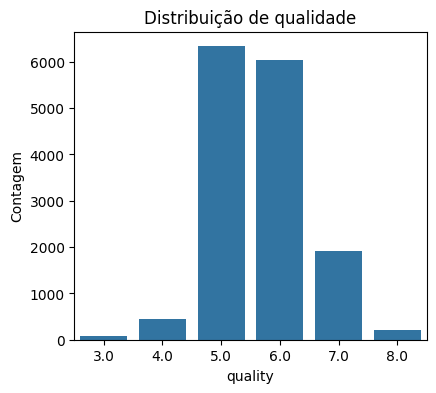

In [122]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x='quality', data=train, stat = 'count')
plt.title('Distribuição de qualidade')
plt.xlabel('quality')
plt.ylabel('Contagem')
plt.show()

# Histograma coluna qualidade

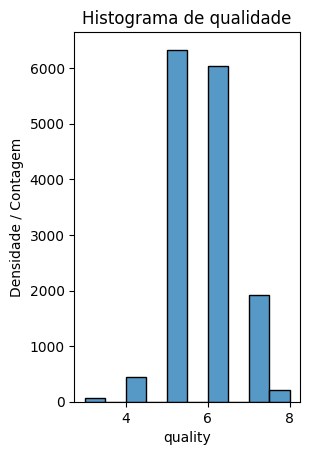

In [123]:
plt.subplot(1,2,2)
sns.histplot(train['quality'], bins=10)
plt.title('Histograma de qualidade')
plt.xlabel('quality')
plt.ylabel('Densidade / Contagem')
plt.show()

# Histograma de todas as outras colunas

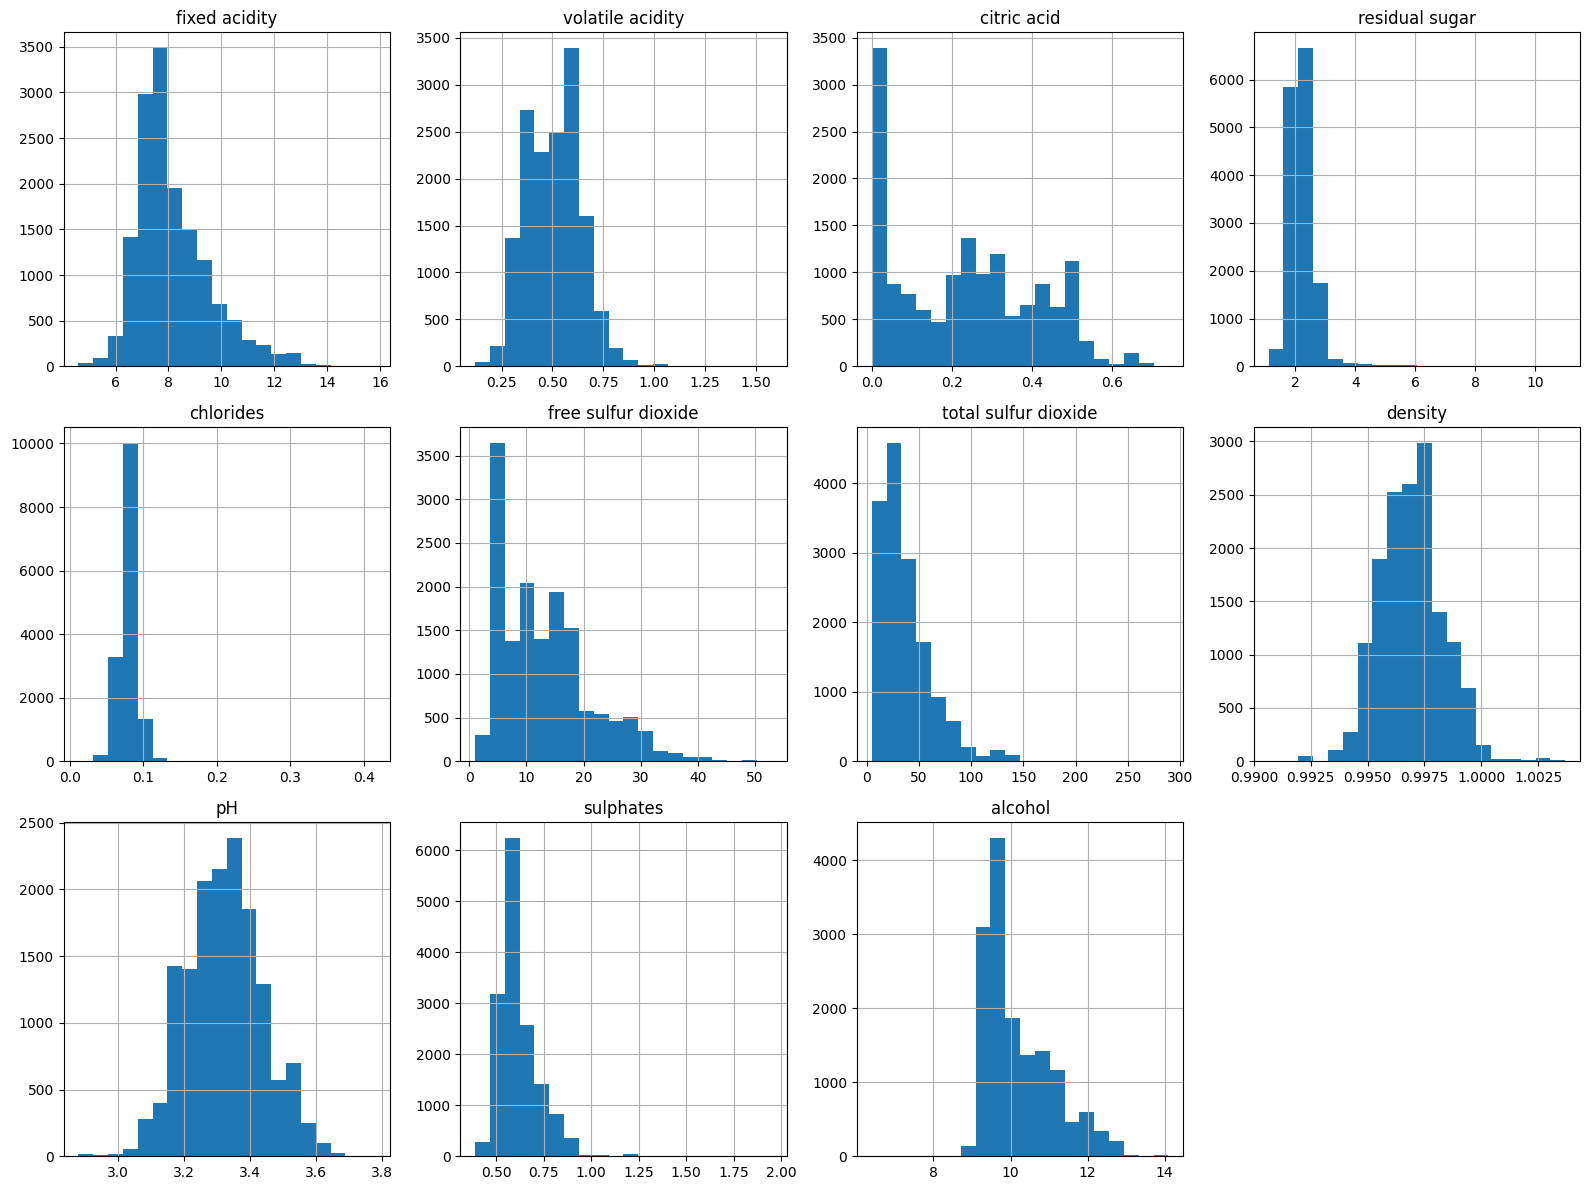

In [124]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('quality') # tira a coluna qualidade
train[num_cols].hist(bins=20, figsize=(16,12), layout=(int(np.ceil(len(num_cols)/4)),4))
plt.tight_layout()
plt.show()

# Boxplots para checar outliers por coluna

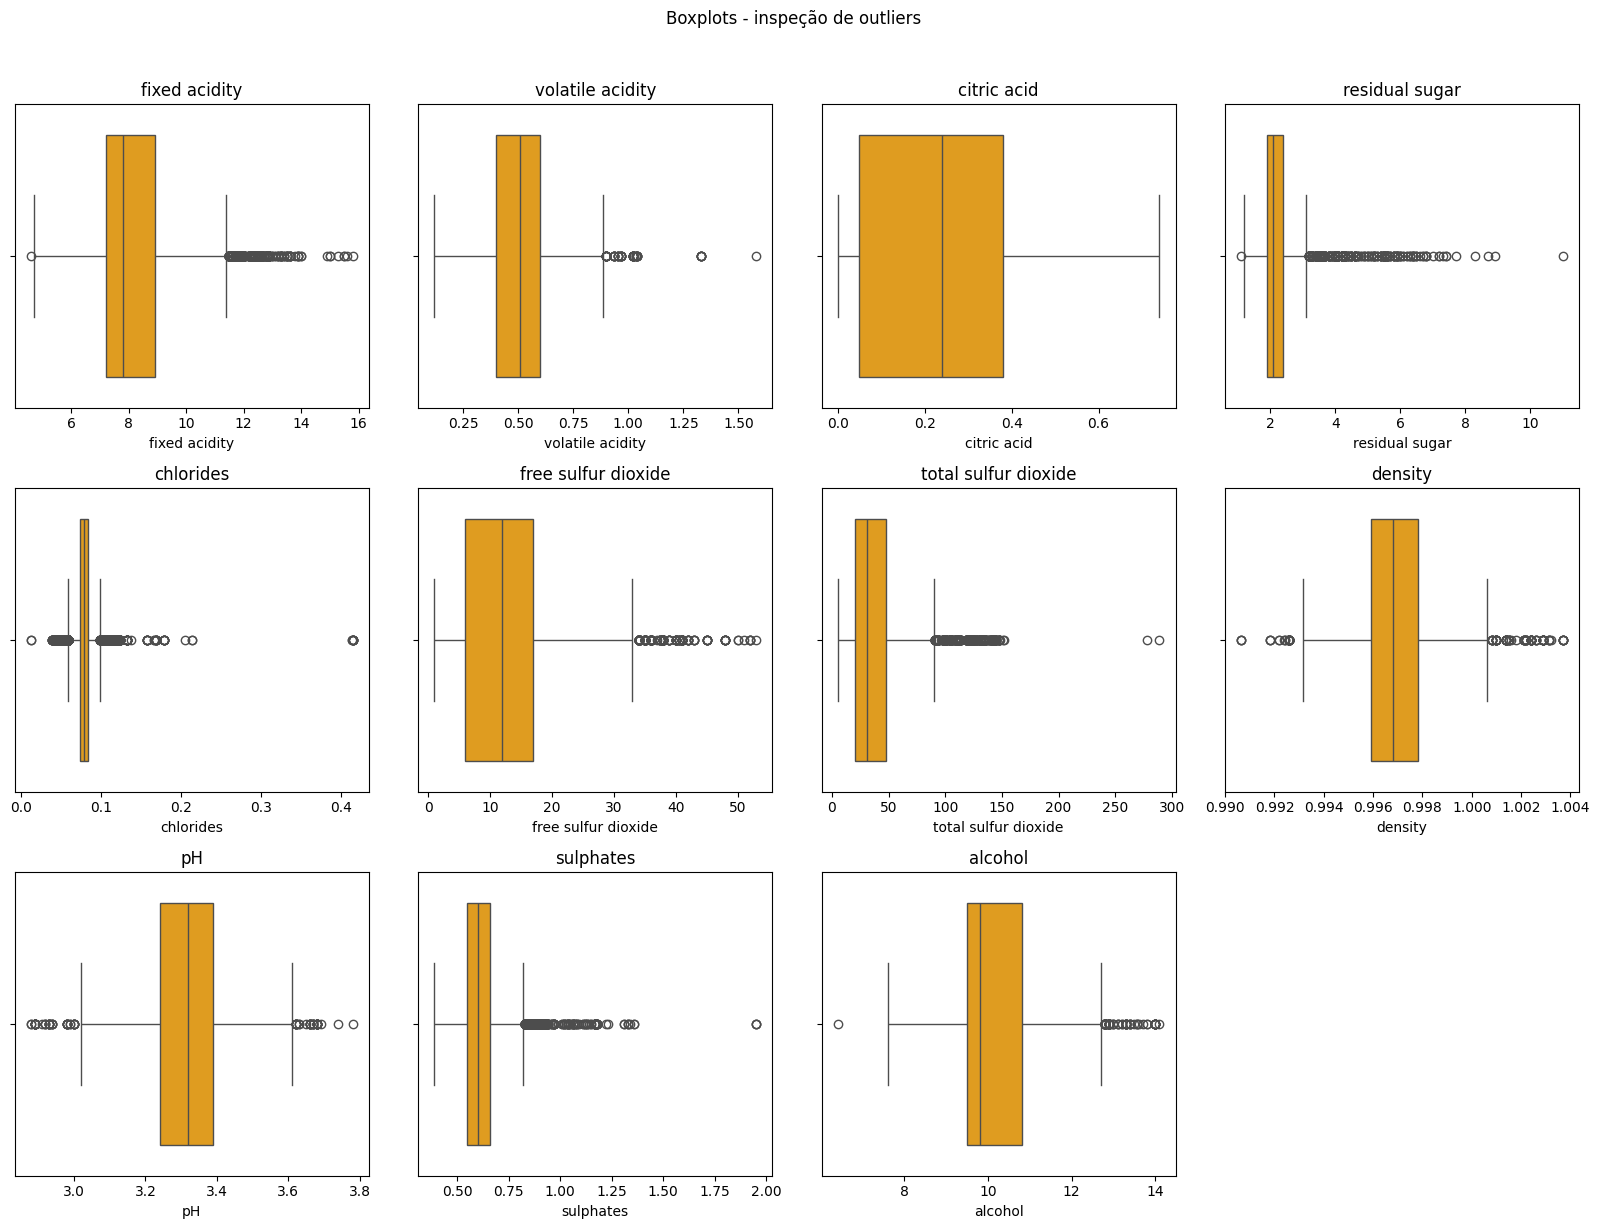

In [125]:

plt.figure(figsize=(16,12))
cols_per_row = 4
rows = int(np.ceil(len(num_cols)/cols_per_row))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=train[col], color='orange')
    plt.title(col)
plt.suptitle('Boxplots - inspeção de outliers', y=1.02)
plt.tight_layout()
plt.show()

# Remoção de outliers

In [126]:
iso_forest = IsolationForest(contamination=0.2, random_state=42)
outlier_predictions = iso_forest.fit_predict(train)
train = train[outlier_predictions == 1] 


# Matriz de correlação entre colunas

In [127]:
corr = train.corr()
corr 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.296294,0.560044,0.041715,0.041040,-0.090268,-0.048116,0.161380,-0.368344,0.132283,-0.023512,-0.009701
volatile acidity,-0.296294,1.000000,-0.649510,-0.045086,-0.045546,-0.007609,-0.028037,-0.058297,0.215353,-0.162311,-0.028911,0.007783
citric acid,0.560044,-0.649510,1.000000,0.064834,0.063965,-0.008266,0.024209,0.137428,-0.396765,0.202818,0.018981,-0.009789
residual sugar,0.041715,-0.045086,0.064834,1.000000,0.037759,0.001302,0.011957,0.019552,-0.027934,0.007103,0.051348,0.011905
chlorides,0.041040,-0.045546,0.063965,0.037759,1.000000,0.017109,0.028227,0.045394,-0.032082,0.010540,-0.047913,-0.006268
free sulfur dioxide,-0.090268,-0.007609,-0.008266,0.001302,0.017109,1.000000,0.700982,-0.015760,0.018160,-0.018687,-0.081537,-0.034965
total sulfur dioxide,-0.048116,-0.028037,0.024209,0.011957,0.028227,0.700982,1.000000,0.017123,-0.004479,-0.024847,-0.175344,-0.095410
density,0.161380,-0.058297,0.137428,0.019552,0.045394,-0.015760,0.017123,1.000000,-0.042686,0.019420,-0.106139,-0.033375
pH,-0.368344,0.215353,-0.396765,-0.027934,-0.032082,0.018160,-0.004479,-0.042686,1.000000,-0.075867,0.010046,0.018812
sulphates,0.132283,-0.162311,0.202818,0.007103,0.010540,-0.018687,-0.024847,0.019420,-0.075867,1.000000,0.057610,0.055172


# Heatmap

<Axes: >

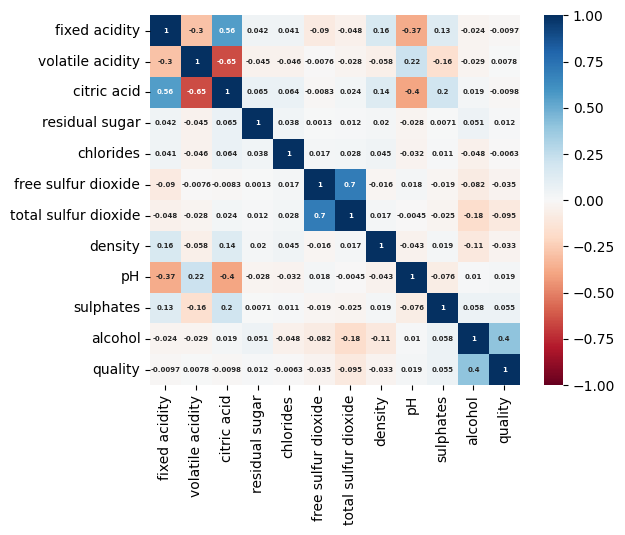

In [128]:
sns.heatmap(corr,cmap = 'RdBu', vmin = -1.0, vmax = 1.0,annot=True,square=True, annot_kws = {'fontsize' : 5, 'fontweight' : 'bold'}) 


# Separar Atributos mais `Correlacionados `

In [129]:
corr_with_quality = abs(corr['quality']).sort_values(ascending=False) #ordenar por nivel de correlação com qualidade
print("Correlações com 'quality':") # correlação com o target qualidade (Y)
print(corr_with_quality)
important_features = corr_with_quality[corr_with_quality > 0.009].index.tolist() #pegar nossos candidatos pro valor de X, correlaçao > 0,05
important_features.remove('quality') #tirar qualidade dos candidatos

print("\nFeatures mais importantes:")
print(important_features) # mostrar candidatos pra analise

Correlações com 'quality':
quality                 1.000000
alcohol                 0.404455
total sulfur dioxide    0.095410
sulphates               0.055172
free sulfur dioxide     0.034965
density                 0.033375
pH                      0.018812
residual sugar          0.011905
citric acid             0.009789
fixed acidity           0.009701
volatile acidity        0.007783
chlorides               0.006268
Name: quality, dtype: float64

Features mais importantes:
['alcohol', 'total sulfur dioxide', 'sulphates', 'free sulfur dioxide', 'density', 'pH', 'residual sugar', 'citric acid', 'fixed acidity']


# Treinamento e Avaliacao com cada modelo proposto

```
- Linear Regression
- Random Forest
- Gradient Boosting 
```

In [130]:
X = train[important_features] #preparar X e y
y = train['quality']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42) #80/20 e definicao de seed padrao 42 

scaler = RobustScaler() # normalizacao por RobustScaler 
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

train_results = {} #dicionarios para armazenar resultados
val_results = {}

#treinar e avaliar cada modelo
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)
    train_results[name] = {
        'R2': r2_score(y_train, y_train_pred),
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred))
    }                   
    val_results[name] = {
        'R2': r2_score(y_val, y_val_pred,),
        'MAE': mean_absolute_error(y_val, y_val_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_val_pred))
    }

# Resultados de Treino


Resultados da Avaliação dos Modelos de treino:
      Linear Regression  Random Forest  Gradient Boosting
R2               0.1681         0.8806             0.2194
MAE              0.5450         0.2026             0.5303
RMSE             0.6613         0.2506             0.6406


<Figure size 1200x600 with 0 Axes>

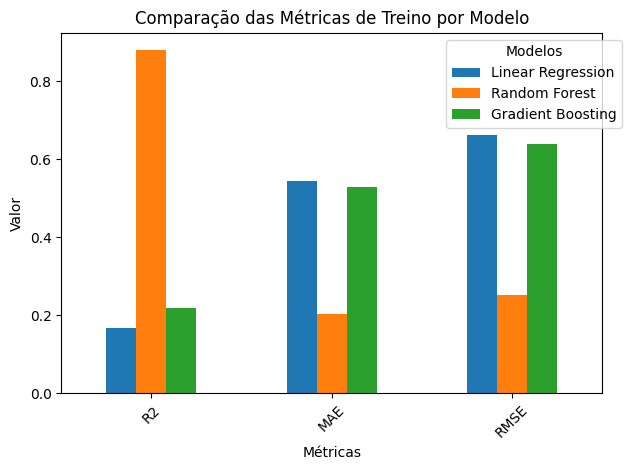

In [131]:
train_results_df = pd.DataFrame(train_results).round(4) 
print("\nResultados da Avaliação dos Modelos de treino:")
print(train_results_df)
plt.figure(figsize=(12, 6)) #plotar os resultados
train_results_df.plot(kind='bar')
plt.title('Comparação das Métricas de Treino por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Resultados de Validacao


Resultados da Avaliação dos Modelos de validacao:
      Linear Regression  Random Forest  Gradient Boosting
R2               0.1351         0.0811             0.1400
MAE              0.5412         0.5516             0.5415
RMSE             0.6519         0.6719             0.6500


<Figure size 1200x600 with 0 Axes>

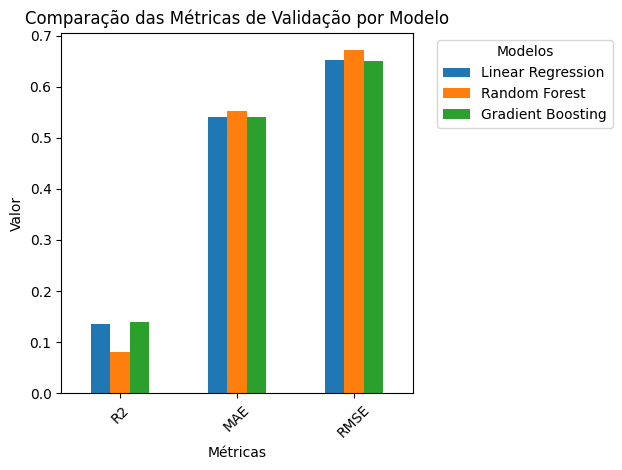

In [132]:
val_results_df = pd.DataFrame(val_results).round(4) #criar data frame pra mostrar resultados
print("\nResultados da Avaliação dos Modelos de validacao:")
print(val_results_df)
plt.figure(figsize=(12, 6)) #plotar os resultados
val_results_df.plot(kind='bar')
plt.title('Comparação das Métricas de Validação por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Selecao do(s) melhor(es) modelo(s):

```
- RMSE < 0.65
- R² > 0.35
- Diff RMSE < 0.15
```

In [133]:

rmse_diff = {model: abs(train_results[model]['RMSE'] - val_results[model]['RMSE']) for model in models}
print('\nVerificação completa dos critérios:')
for model_name in models:
    print(f"\nModelo: {model_name}")
    rmse_ok = val_results[model_name]['RMSE'] < 0.651
    r2_ok = val_results[model_name]['R2'] > 0.35
    diff_ok = rmse_diff[model_name] < 0.15
    print(f"- RMSE < 0.65: {'sim' if rmse_ok else 'nao'} ({val_results[model_name]['RMSE']:.4f})")
    print(f"- R² > 0.35: {'sim' if r2_ok else 'nao'} ({val_results[model_name]['R2']:.4f})")
    print(f"- Diff RMSE < 0.15: {'sim' if diff_ok else 'nao'} ({rmse_diff[model_name]:.4f})")
    print(f"Todos critérios atendidos: {'sim' if (rmse_ok and r2_ok and diff_ok) else 'nao'}")


Verificação completa dos critérios:

Modelo: Linear Regression
- RMSE < 0.65: nao (0.6519)
- R² > 0.35: nao (0.1351)
- Diff RMSE < 0.15: sim (0.0095)
Todos critérios atendidos: nao

Modelo: Random Forest
- RMSE < 0.65: nao (0.6719)
- R² > 0.35: nao (0.0811)
- Diff RMSE < 0.15: nao (0.4214)
Todos critérios atendidos: nao

Modelo: Gradient Boosting
- RMSE < 0.65: sim (0.6500)
- R² > 0.35: nao (0.1400)
- Diff RMSE < 0.15: sim (0.0094)
Todos critérios atendidos: nao


**Modelo selecionado : Gradient Boosting**


# Definicao de K otimo utilizando Metodo do cotovelo

2 : 4.420431455085516
3 : 3.7526999855204424
4 : 3.423534601638483
5 : 3.1940703780942576


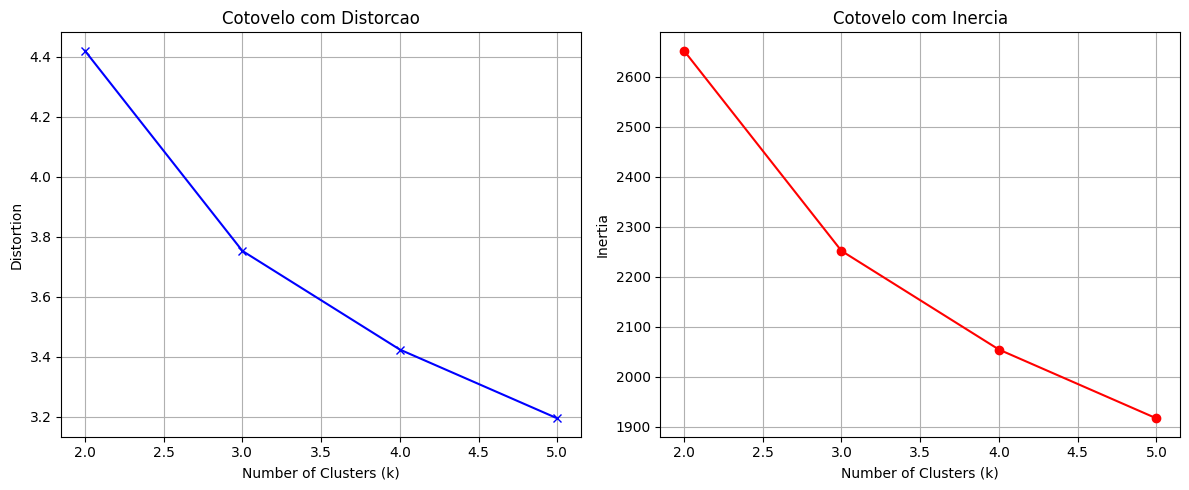

In [134]:
y_selected = models["Gradient Boosting"].predict(X_val_scaled)

# Aplicar PCA para reduzir a 2 dimensões para visualização
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_val_scaled)

K = range(2, 6)
distortion = []
inertia = []
mapping_distortion = {}
mapping_inertia = {}

for k in K:  # Testando para valores de K ótimo
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X_val_scaled)
    
    distortion.append(sum(np.min(cdist(X_val_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_val_scaled.shape[0])
    inertia.append(kmeanModel.inertia_)
    
    mapping_distortion[k] = distortion[-1]
    mapping_inertia[k] = inertia[-1]
    
for key, val in mapping_distortion.items():
    print(f'{key} : {val}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, distortion, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('Cotovelo com Distorcao')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(K, inertia, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Cotovelo com Inercia')
plt.grid()

plt.tight_layout()
plt.show()


# Geracao de Grafico de visualizacao de Clusters para analise final de K otimo

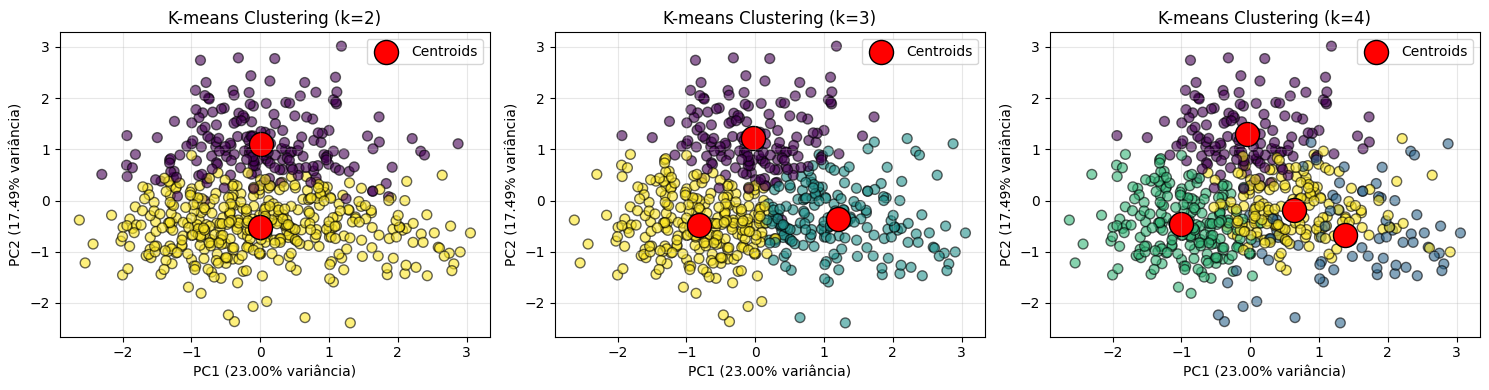


 K = 2 clusters
  Cluster 1: 191 elementos (31.83%)
  Cluster 2: 409 elementos (68.17%)
  Total: 600 elementos

 K = 3 clusters
  Cluster 1: 155 elementos (25.83%)
  Cluster 2: 182 elementos (30.33%)
  Cluster 3: 263 elementos (43.83%)
  Total: 600 elementos

 K = 4 clusters
  Cluster 1: 139 elementos (23.17%)
  Cluster 2: 75 elementos (12.50%)
  Cluster 3: 209 elementos (34.83%)
  Cluster 4: 177 elementos (29.50%)
  Total: 600 elementos


In [135]:
k_range = range(2, 5)
# Range Sugerido pelo enunciado

plt.figure(figsize=(15, 4))

for idx, k in enumerate(k_range, 1):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X_val_scaled)
    
    # Transformar centróides para o espaço PCA
    centers_pca = pca_viz.transform(kmeans.cluster_centers_)
    
    #Plotar grafico PCA
    
    plt.subplot(1, 3, idx)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=50, alpha=0.6)
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=300, c='red', label='Centroids', edgecolor='k', marker='o')
    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variância)')
    plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variância)')
    plt.legend()
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Mostrar quantidade de elementos por cluster pra cada K testado
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X_val_scaled)
    
    unique, counts = np.unique(y_kmeans, return_counts=True)
    
    print(f"\n K = {k} clusters")
    total = 0
    for cluster_id, count in zip(unique, counts):
        percentage = (count / len(y_kmeans)) * 100
        print(f"  Cluster {cluster_id+1}: {count} elementos ({percentage:.2f}%)")
        total += count
    print(f"  Total: {total} elementos")


*K = 3 como K otimo*

In [136]:
# Análise da qualidade média por cluster (k=3)
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans_optimal.fit_predict(X_val_scaled)

# Criar dataframe com clusters e qualidades
analysis_df = pd.DataFrame({
    'Cluster': clusters,
    'Quality': y_val.values
})

# Calcular qualidade média por cluster
quality_by_cluster = analysis_df.groupby('Cluster')['Quality'].agg(['mean', 'std', 'count'])
print("\nQualidade Média por Cluster (k=3):")
print(quality_by_cluster)

# Encontrar cluster com maior qualidade média
best_cluster = quality_by_cluster['mean'].idxmax()
best_quality = quality_by_cluster.loc[best_cluster, 'mean']

print(f"\nCluster com MAIOR qualidade média: {best_cluster}")
print(f"Qualidade média: {best_quality:.4f}")
print(f"Número de elementos: {int(quality_by_cluster.loc[best_cluster, 'count'])}")
print(f"Desvio padrão: {quality_by_cluster.loc[best_cluster, 'std']:.4f}")

# Selecionar dados do cluster com melhor qualidade
best_cluster_data = analysis_df[analysis_df['Cluster'] == best_cluster]
print(f"\nDados selecionados do Cluster {best_cluster}:")
print(f"  Total de elementos: {len(best_cluster_data)}")
print(f"  Qualidade mínima: {best_cluster_data['Quality'].min():.4f}")
print(f"  Qualidade máxima: {best_cluster_data['Quality'].max():.4f}")



Qualidade Média por Cluster (k=3):
             mean       std  count
Cluster                           
0        5.503226  0.628069    155
1        5.664835  0.722775    182
2        5.695817  0.719588    263

Cluster com MAIOR qualidade média: 2
Qualidade média: 5.6958
Número de elementos: 263
Desvio padrão: 0.7196

Dados selecionados do Cluster 2:
  Total de elementos: 263
  Qualidade mínima: 4.0000
  Qualidade máxima: 8.0000


# Carregar CSV com atributos faltantes (Já fornecido) pra um dataframe
## E verificar se a porcentagem média de itens faltantes (~20%) esta sendo seguida pra todos os Atributos


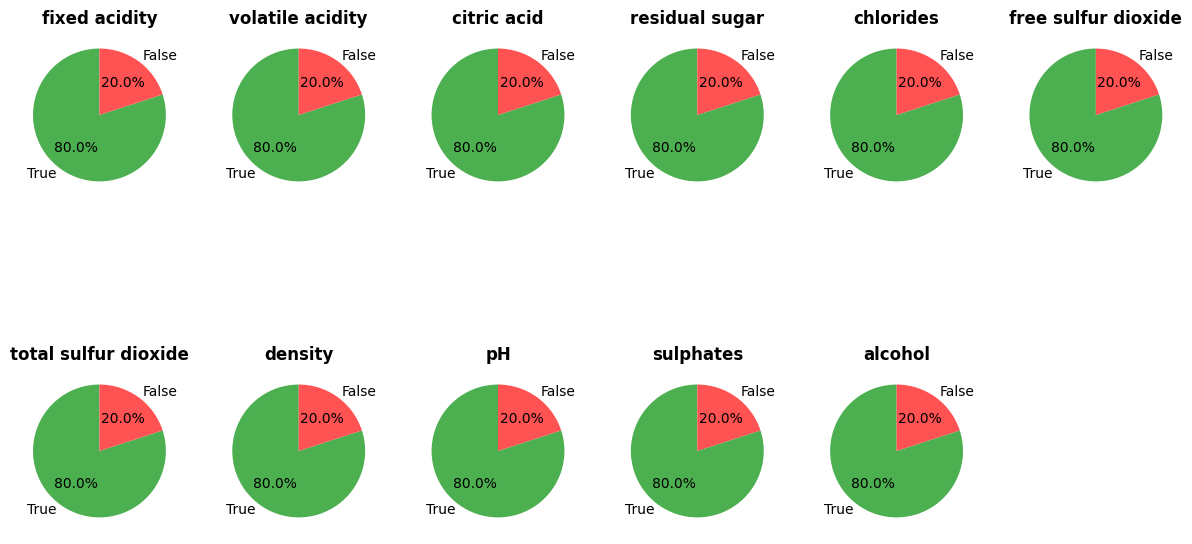

In [137]:

missing = pd.read_csv("test_with_missing_features.csv",  index_col= 0)

control = 0
control = missing.notna() #Troca valores não vazios por True e valores vazios por False

n_cols_plot = 6
n_cols_df = len(control.columns)
n_rows_plot = (n_cols_df + n_cols_plot - 1) // n_cols_plot # Organizacao dos graficos (11) no total

# Criar a figura e os eixos
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten() 

for i, col in enumerate(control.columns):
    # Contagem de True/False para a coluna atual do dataframe 'control'
    contagem = control[col].value_counts()
    axes[i].pie(contagem, 
                labels=contagem.index, 
                autopct='%1.1f%%', 
                startangle=90,
                colors=['#4CAF50', '#FF5252']) # Verde (True), Vermelho (False)
    
    axes[i].set_title(col, fontsize=12, fontweight='bold')

# Remover eixos que sobraram vazios no final do grid por não ser multiplo de 6
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()


- *Valores faltantes todos na faixa dos 20%*
- **Logo, podemos continuar**

In [138]:
def treinar_modelo_feature(feature_name, train_data):
    """
    Treina um modelo para prever uma feature específica
    """
    # Separar features preditoras (todas exceto id, quality, e a feature alvo)
    all_features = train_data.columns.tolist()
    predictor_features = [col for col in all_features if col not in ['quality', feature_name]]
    # Preparar dados de treino (remover linhas com valores faltantes na feature alvo)
    train_clean = train_data.dropna(subset=[feature_name])
    X = train_clean[predictor_features]
    y = train_clean[feature_name]
    # Normalizar dados com RobustScaler 
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    # Treinar Gradient Boosting
    model = GradientBoostingRegressor(random_state=42)
    model.fit(X_scaled, y)
    # Retornar modelo, scaler e lista de features
    return model, scaler, predictor_features

In [139]:
# Identificar features com valores faltantes
features_with_missing = missing.columns[missing.isnull().any()].tolist()
print("Features com valores faltantes:")
print(features_with_missing)
print(f"\nTotal de features para completar: {len(features_with_missing)}")


Features com valores faltantes:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Total de features para completar: 11


In [140]:
# Treinar modelos para cada feature com valores faltantes
trained_models = {}
scalers = {}
feature_lists = {}

print("Treinando modelos para completar features faltantes...\n")

for feature in features_with_missing:
    print(f"Treinando modelo para: {feature}")
    model, scaler, predictor_features = treinar_modelo_feature(feature, train)
    trained_models[feature] = model
    scalers[feature] = scaler
    feature_lists[feature] = predictor_features
    print(f"  ✓ Modelo treinado com sucesso\n")

print("Todos os modelos foram treinados!")


Treinando modelos para completar features faltantes...

Treinando modelo para: fixed acidity
  ✓ Modelo treinado com sucesso

Treinando modelo para: volatile acidity
  ✓ Modelo treinado com sucesso

Treinando modelo para: citric acid
  ✓ Modelo treinado com sucesso

Treinando modelo para: residual sugar
  ✓ Modelo treinado com sucesso

Treinando modelo para: chlorides
  ✓ Modelo treinado com sucesso

Treinando modelo para: free sulfur dioxide
  ✓ Modelo treinado com sucesso

Treinando modelo para: total sulfur dioxide
  ✓ Modelo treinado com sucesso

Treinando modelo para: density
  ✓ Modelo treinado com sucesso

Treinando modelo para: pH
  ✓ Modelo treinado com sucesso

Treinando modelo para: sulphates
  ✓ Modelo treinado com sucesso

Treinando modelo para: alcohol
  ✓ Modelo treinado com sucesso

Todos os modelos foram treinados!


In [141]:
# Completar valores faltantes no CSV de teste
missing_filled = missing.copy()

# Criar um imputer para valores faltantes nas features preditoras
imputer = SimpleImputer(strategy='median')

print("Preenchendo valores faltantes...\n")

for feature in features_with_missing:
    # Encontrar índices com valores faltantes
    missing_indices = missing_filled[missing_filled[feature].isnull()].index
    
    if len(missing_indices) > 0:
        print(f"Preenchendo {len(missing_indices)} valores para: {feature}")
        
        # Preparar dados para predição
        X_test = missing_filled.loc[missing_indices, feature_lists[feature]].copy()
        
        # Aplicar imputer para lidar com valores faltantes nas features preditoras
        X_test_imputed = imputer.fit_transform(X_test)
        X_test_imputed = pd.DataFrame(X_test_imputed, columns=feature_lists[feature], index=missing_indices)
        
        # Normalizar com o scaler treinado
        X_test_scaled = scalers[feature].transform(X_test_imputed)
        
        # Fazer predições
        predictions = trained_models[feature].predict(X_test_scaled)
        
        # Preencher valores faltantes
        missing_filled.loc[missing_indices, feature] = predictions
        print(f"  ✓ {len(missing_indices)} valores preenchidos\n")

print("Completamento finalizado!")

Preenchendo valores faltantes...

Preenchendo 2000 valores para: fixed acidity
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: volatile acidity
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: citric acid
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: residual sugar
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: chlorides
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: free sulfur dioxide
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: total sulfur dioxide
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: density
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: pH
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: sulphates
  ✓ 2000 valores preenchidos

Preenchendo 2000 valores para: alcohol
  ✓ 2000 valores preenchidos

Completamento finalizado!


In [142]:
# Verificar se não há mais valores faltantes
print("Verificação final:")
print(f"Valores faltantes restantes: {missing_filled.isnull().sum().sum()}")
print(f"\nShape do CSV preenchido: {missing_filled.shape}")

# Salvar CSV completo
output_file = "test_filled.csv"
missing_filled.to_csv(output_file)
print(f"\n✓ CSV completo salvo em: {output_file}")

# Mostrar amostra dos dados preenchidos
print("\nAmostra dos dados preenchidos:")
print(missing_filled.head(10))


Verificação final:
Valores faltantes restantes: 0

Shape do CSV preenchido: (10000, 11)

✓ CSV completo salvo em: test_filled.csv

Amostra dos dados preenchidos:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
id                                                                    
15000       7.044543          0.560000     0.020000        2.300000   
15001       7.100000          0.402066     0.490000        2.300000   
15002       7.100000          0.310000     0.341551        2.135511   
15003       7.598023          0.584452     0.080000        2.124821   
15004      11.900000          0.310000     0.490000        2.000000   
15005       7.800000          0.430000     0.130000        2.000000   
15006       7.900000          0.393048     0.330000        2.300000   
15007       6.400000          0.380000     0.270000        2.100000   
15008       7.943318          0.440000     0.270000        2.227055   
15009       9.100000          0.520000     0.220000      

# Validação dos Dados Imputados
## Comparação: Original vs Imputado

In [143]:
# Calcular diferença de média e desvio padrão

comparison_stats = []

for feature in features_with_missing:
    # Dados originais (treino)
    original_mean = train[feature].mean()
    original_std = train[feature].std()
    
    # Dados imputados
    imputado_mean = missing_filled[feature].mean()
    imputado_std = missing_filled[feature].std()
    
    # Calcular diferenças percentuais
    diff_mean_pct = abs(imputado_mean - original_mean) / original_mean * 100 if original_mean != 0 else 0
    diff_std_pct = abs(imputado_std - original_std) / original_std * 100 if original_std != 0 else 0
    
    comparison_stats.append({
        'Feature': feature,
        'Original_Mean': original_mean,
        'Imputado_Mean': imputado_mean,
        'Diff_Mean_%': diff_mean_pct,
        'Original_Std': original_std,
        'Imputado_Std': imputado_std,
        'Diff_Std_%': diff_std_pct
    })
    
    print(f"\n{feature}:")
    print(f"  Média Original: {original_mean:.6f} | Imputado: {imputado_mean:.6f} | Diferença: {diff_mean_pct:.2f}%")
    print(f"  Std Original:   {original_std:.6f} | Imputado: {imputado_std:.6f} | Diferença: {diff_std_pct:.2f}%")

comparison_df = pd.DataFrame(comparison_stats)
print("\n" + "=" * 80)
print("TABELA RESUMIDA")
print("=" * 80)
print(comparison_df.round(6).to_string())



fixed acidity:
  Média Original: 8.004192 | Imputado: 8.132919 | Diferença: 1.61%
  Std Original:   1.165998 | Imputado: 1.286266 | Diferença: 10.31%

volatile acidity:
  Média Original: 0.509498 | Imputado: 0.508295 | Diferença: 0.24%
  Std Original:   0.125454 | Imputado: 0.125973 | Diferença: 0.41%

citric acid:
  Média Original: 0.216004 | Imputado: 0.226715 | Diferença: 4.96%
  Std Original:   0.163212 | Imputado: 0.167726 | Diferença: 2.77%

residual sugar:
  Média Original: 2.140212 | Imputado: 2.176659 | Diferença: 1.70%
  Std Original:   0.354523 | Imputado: 0.447158 | Diferença: 26.13%

chlorides:
  Média Original: 0.077859 | Imputado: 0.078547 | Diferença: 0.88%
  Std Original:   0.009618 | Imputado: 0.011128 | Diferença: 15.69%

free sulfur dioxide:
  Média Original: 12.177875 | Imputado: 13.063224 | Diferença: 7.27%
  Std Original:   6.734166 | Imputado: 7.433039 | Diferença: 10.38%

total sulfur dioxide:
  Média Original: 34.077500 | Imputado: 37.320221 | Diferença: 9.52

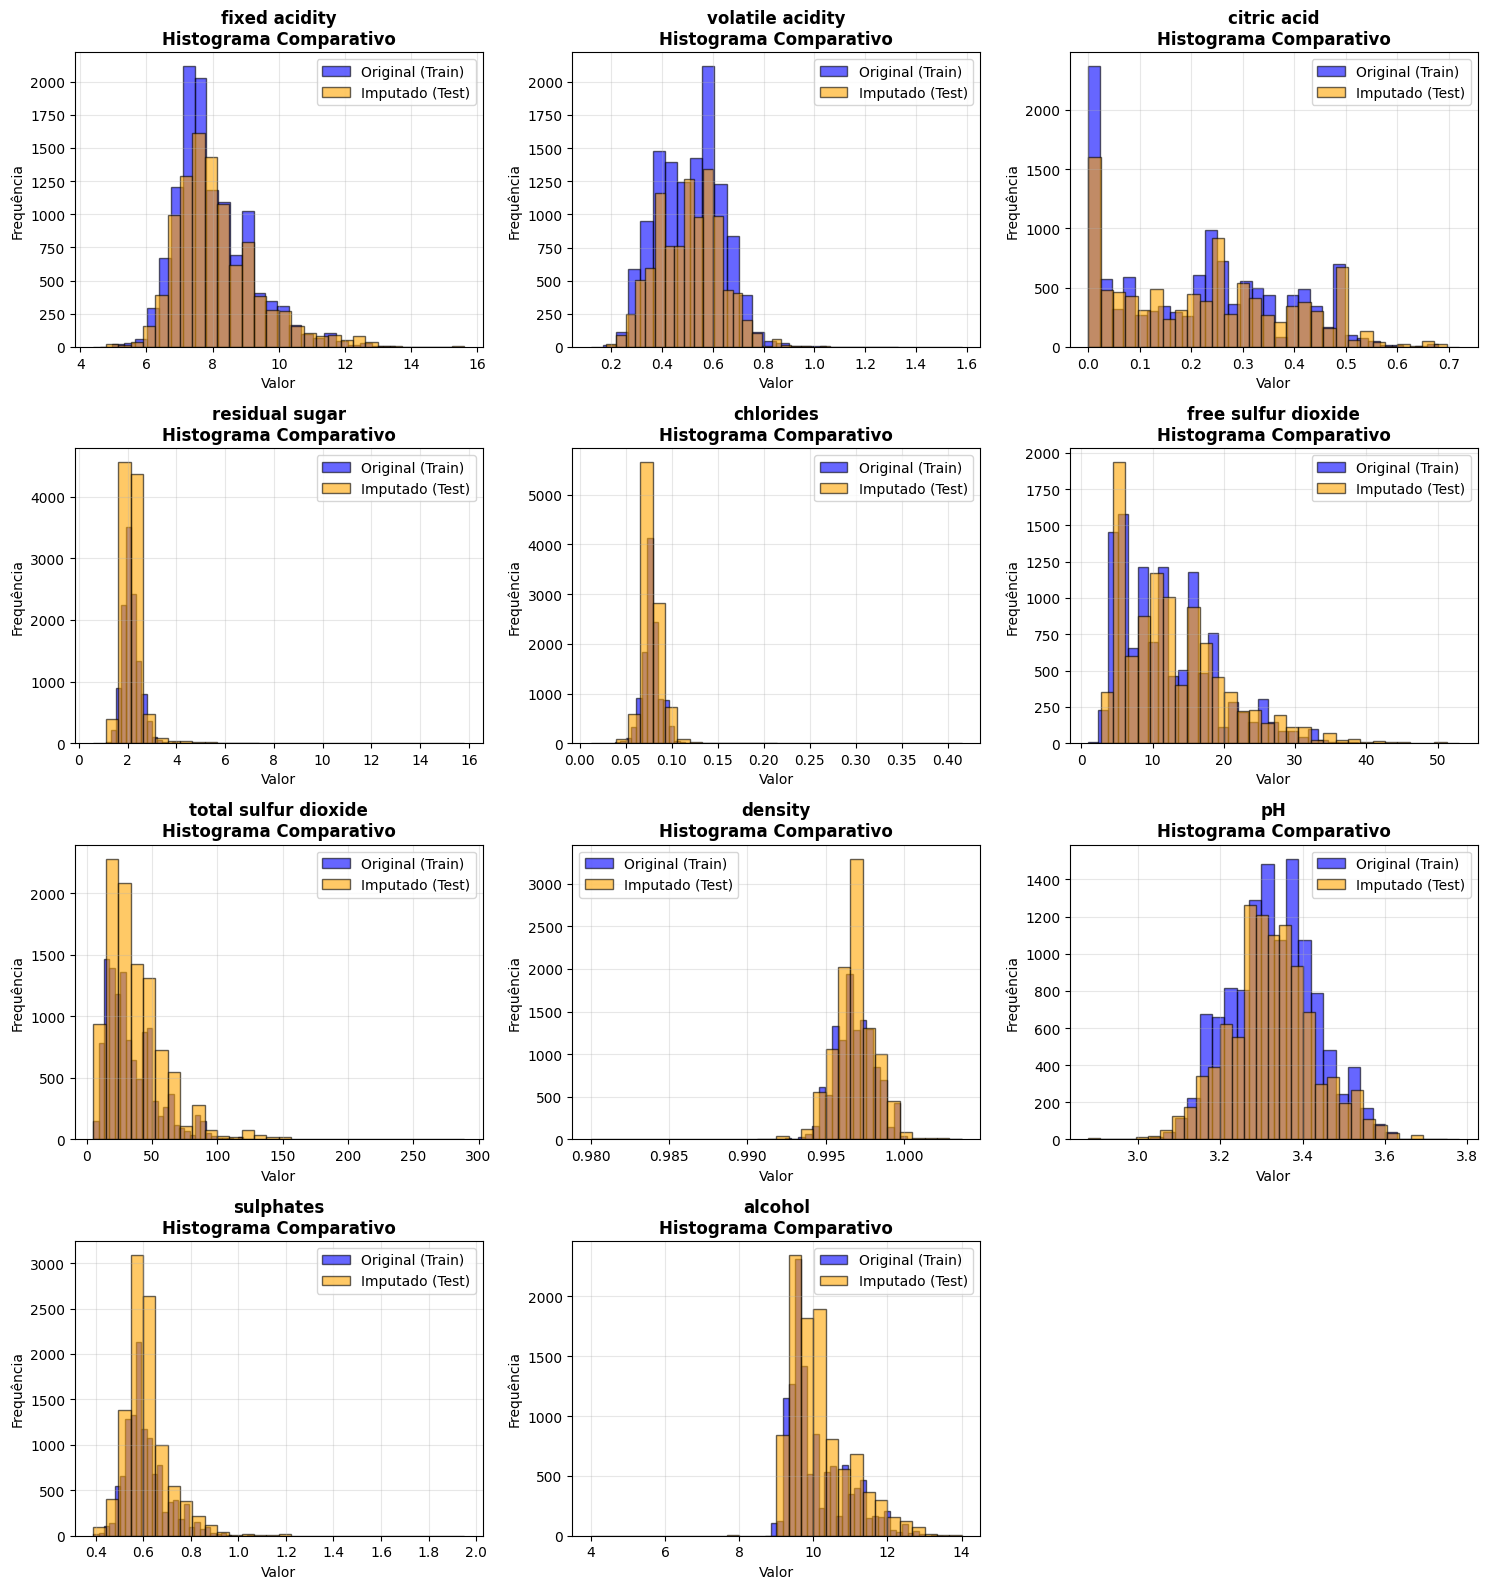

In [144]:
# Visualizações comparativas - Histogramas
n_features = len(features_with_missing)
cols_per_row = 3
n_rows = int(np.ceil(n_features / cols_per_row))

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features_with_missing):
    ax = axes[idx]
    
    # Plotar histogramas sobrepostos
    ax.hist(train[feature], bins=30, alpha=0.6, label='Original (Train)', color='blue', edgecolor='black')
    ax.hist(missing_filled[feature], bins=30, alpha=0.6, label='Imputado (Test)', color='orange', edgecolor='black')
    
    ax.set_title(f'{feature}\nHistograma Comparativo', fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend()
    ax.grid(alpha=0.3)

# Remover eixos vazios
for idx in range(len(features_with_missing), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

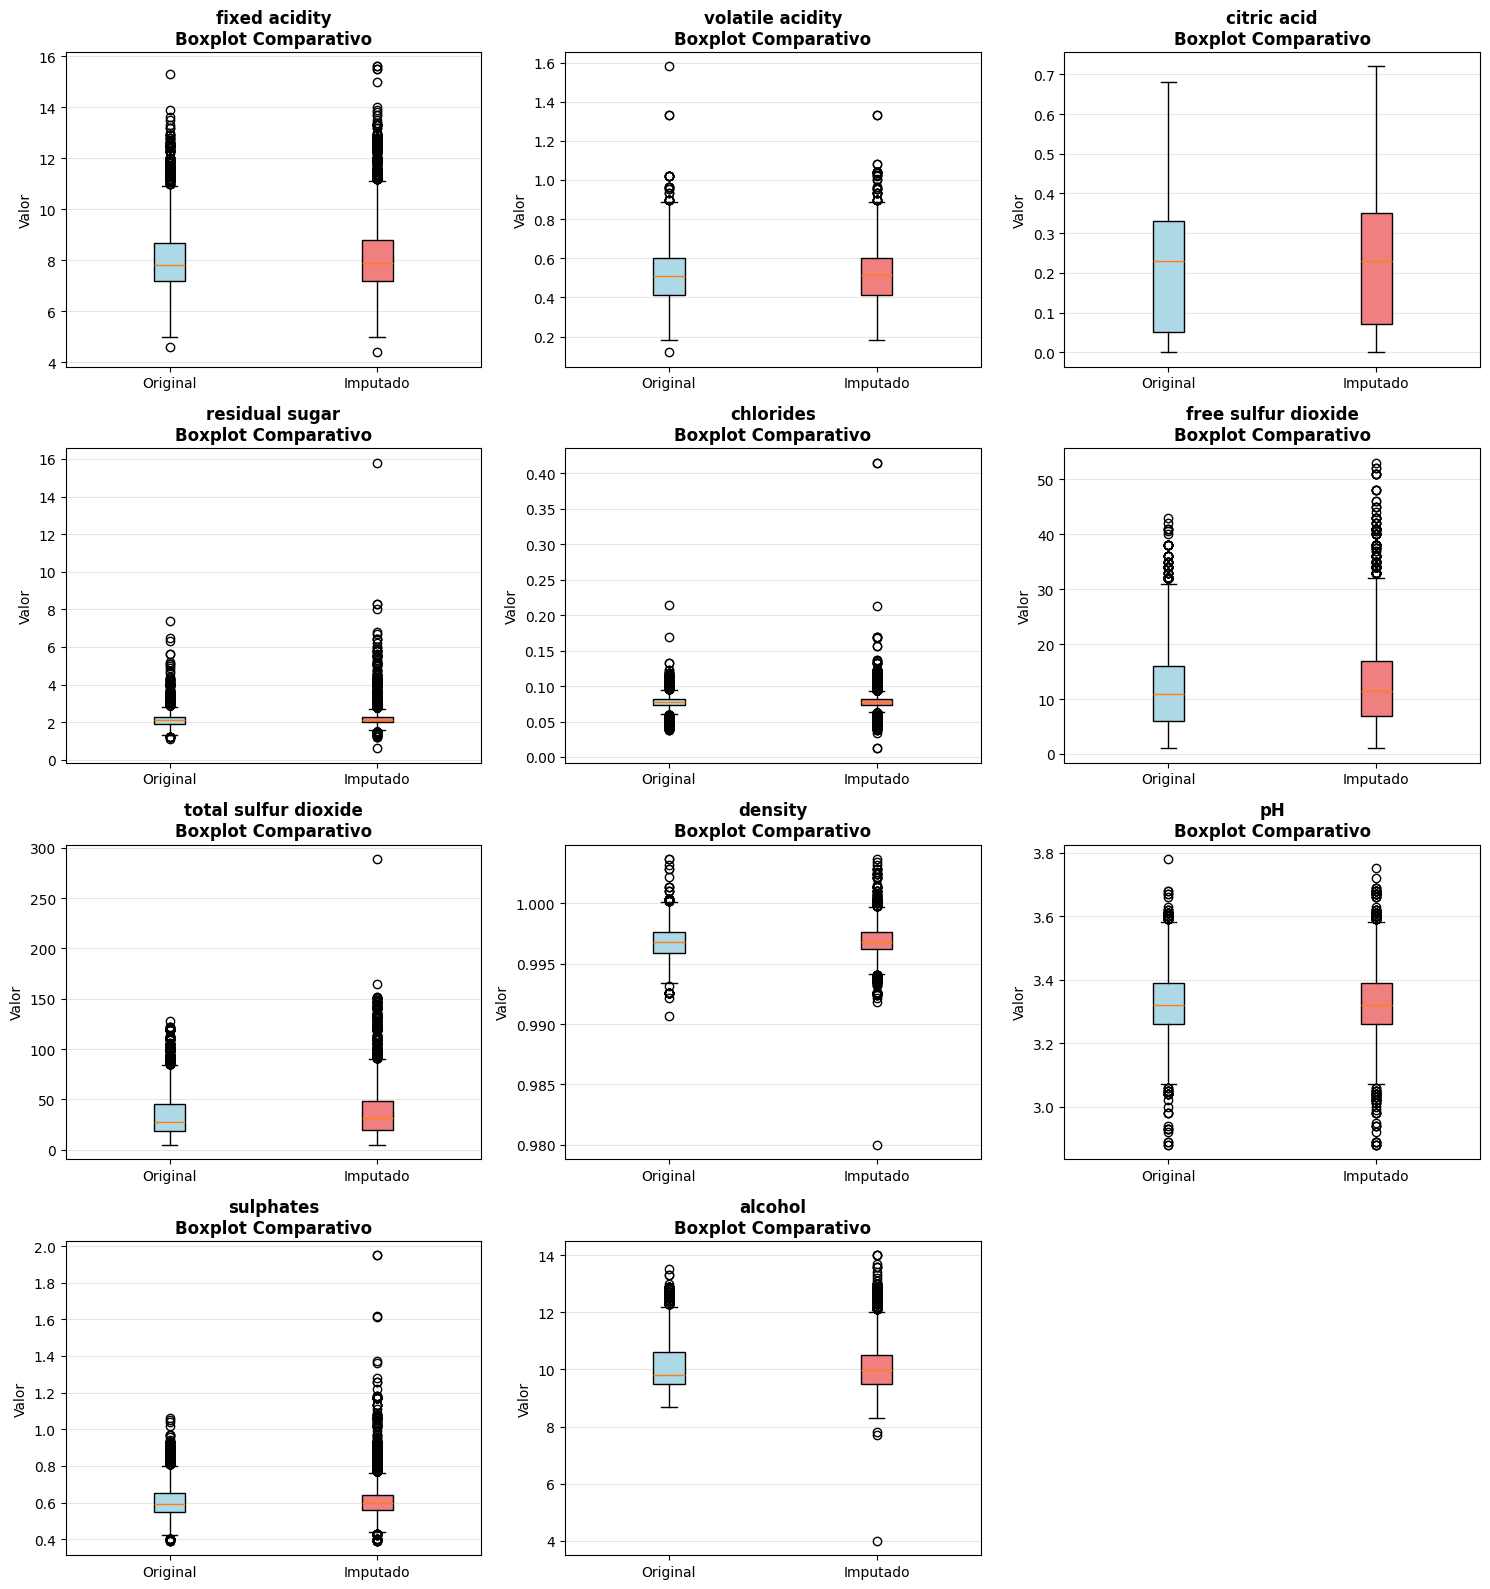

In [145]:
# Visualizações comparativas - Boxplots
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features_with_missing):
    ax = axes[idx]
    
    # Preparar dados para boxplot lado a lado
    data_to_plot = [train[feature].dropna(), missing_filled[feature]]
    
    bp = ax.boxplot(data_to_plot, tick_labels=['Original', 'Imputado'], patch_artist=True)
    
    # Colorir os boxplots
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{feature}\nBoxplot Comparativo', fontweight='bold')
    ax.set_ylabel('Valor')
    ax.grid(alpha=0.3, axis='y')

# Remover eixos vazios
for idx in range(len(features_with_missing), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [146]:
# Salvar dataset imputado
print("=" * 80)
print("SALVANDO DATASET IMPUTADO")
print("=" * 80)

# Salvar em diferentes formatos
csv_output = "test_filled_validated.csv"
missing_filled.to_csv(csv_output)
print(f"\n✓ Dataset salvo em CSV: {csv_output}")
print(f"  Shape: {missing_filled.shape}")
print(f"  Valores faltantes: {missing_filled.isnull().sum().sum()}")

# Exibir resumo final
print("\n" + "=" * 80)
print("RESUMO FINAL")
print("=" * 80)
print(f"\nDataset Imputado:")
print(f"  Total de linhas: {missing_filled.shape[0]}")
print(f"  Total de colunas: {missing_filled.shape[1]}")
print(f"  Features com valores imputados: {len(features_with_missing)}")
print(f"\nFeatures imputadas:")
for feature in features_with_missing:
    print(f"  - {feature}")

print(f"\n✓ Validação e imputação completas!")


SALVANDO DATASET IMPUTADO

✓ Dataset salvo em CSV: test_filled_validated.csv
  Shape: (10000, 11)
  Valores faltantes: 0

RESUMO FINAL

Dataset Imputado:
  Total de linhas: 10000
  Total de colunas: 11
  Features com valores imputados: 11

Features imputadas:
  - fixed acidity
  - volatile acidity
  - citric acid
  - residual sugar
  - chlorides
  - free sulfur dioxide
  - total sulfur dioxide
  - density
  - pH
  - sulphates
  - alcohol

✓ Validação e imputação completas!
